<a href="https://colab.research.google.com/github/Aayushapanda/Autism-Percept-Modelling-with-Hopfield-Network-for-Necker-s-cube/blob/main/References.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#A simple Hopfield Network

In [6]:
import numpy as np
import random
# ---------------------------------------------------
# Stored patterns (binary)
# ---------------------------------------------------

FAP = np.array([1,1,1,0,0,1,1,1,1,1,1,0,0,1,0,1])

FBP = np.array([1,1,0,1,1,1,0,0,0,0,1,1,1,1,1,1])

# Corrupted input
for i in range(16):
    X_in = FAP.copy()
    if np.random.rand() < 0.4:#currupt signal ~40%
       X_in[i] = 1 - X_in[i]

# ---------------------------------------------------
# Convert to bipolar representation {-1,+1}
# ---------------------------------------------------

def to_bipolar(x):
    return 2*x - 1

def to_binary(x):
    return ((x + 1) // 2).astype(int)

FAP_b = to_bipolar(FAP)
FBP_b = to_bipolar(FBP)
X_b   = to_bipolar(X_in)

# ---------------------------------------------------
# Hopfield Weight Matrix (Hebbian Learning)
# ---------------------------------------------------

N = len(FAP)

W = np.zeros((N, N))

patterns = [FAP_b, FBP_b]

W = np.zeros((N, N))

for i in range(N):
    for j in range(N):

        # no self-connections
        if i == j:
            continue

        # Explicit outer-product summation
        W[i, j] = (
            FAP_b[i] * FAP_b[j]
            +
            FBP_b[i] * FBP_b[j]
        ) / N

print("Weight Matrix:\n")
print(W)

# Remove self-connections
np.fill_diagonal(W, 0)

# Normalize
W = W / N


# ---------------------------------------------------
# Hopfield Recall Dynamics
# ---------------------------------------------------

state = X_b.copy()

max_iters = 10

print("\nInitial Corrupted Input:")
print(to_binary(state))

for iteration in range(max_iters):

    prev_state = state.copy()

    # Asynchronous update
    for i in range(N):
        h_i = np.dot(W[i], state)
        # Sign activation
        if h_i >= 0:
            state[i] = 1
        else:
            state[i] = -1
    print(f"\nIteration {iteration+1}:")
    print(to_binary(state))
    # Stop if converged
    if np.array_equal(state, prev_state):
        print("\nNetwork converged.")
        break
# ---------------------------------------------------
# Final Output
# ---------------------------------------------------

final_output = to_binary(state)

print("\nFinal Recalled Pattern:")
print(final_output)

# ---------------------------------------------------
# Compare with stored memories
# ---------------------------------------------------

def hamming(a,b):
    return np.sum(a!=b)

print("\nHamming Distance to FAP:",
      hamming(final_output, FAP))

print("Hamming Distance to FBP:",
      hamming(final_output, FBP))

Weight Matrix:

[[ 0.     0.125  0.     0.     0.     0.125  0.     0.     0.     0.
   0.125  0.     0.     0.125  0.     0.125]
 [ 0.125  0.     0.     0.     0.     0.125  0.     0.     0.     0.
   0.125  0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.    -0.125 -0.125  0.     0.125  0.125  0.125  0.125
   0.    -0.125 -0.125  0.    -0.125  0.   ]
 [ 0.     0.    -0.125  0.     0.125  0.    -0.125 -0.125 -0.125 -0.125
   0.     0.125  0.125  0.     0.125  0.   ]
 [ 0.     0.    -0.125  0.125  0.     0.    -0.125 -0.125 -0.125 -0.125
   0.     0.125  0.125  0.     0.125  0.   ]
 [ 0.125  0.125  0.     0.     0.     0.     0.     0.     0.     0.
   0.125  0.     0.     0.125  0.     0.125]
 [ 0.     0.     0.125 -0.125 -0.125  0.     0.     0.125  0.125  0.125
   0.    -0.125 -0.125  0.    -0.125  0.   ]
 [ 0.     0.     0.125 -0.125 -0.125  0.     0.125  0.     0.125  0.125
   0.    -0.125 -0.125  0.    -0.125  0.   ]
 [ 0.     0.     0.125 -0.125 -0.125  0.     0.125  0.125

#Mimicing V1 with visual cortex Reference image from:
https://pylissom.readthedocs.io/en/latest/notes/visual_cortex.html

The above has the image at the very bottom

(15, 15)


(np.float64(-0.5), np.float64(14.5), np.float64(14.5), np.float64(-0.5))

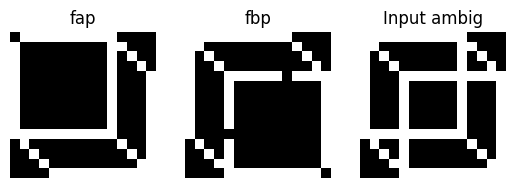

In [7]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np

def draw_line(img, x0, y0, x1, y1, thickness=1, intensity=1.0):
    """Bresenham-style line drawing updated to support variable intensity."""
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    x, y = x0, y0

    sx = 1 if x1 > x0 else -1
    sy = 1 if y1 > y0 else -1

    if dx > dy:
        err = dx / 2.0
        while x != x1:
            for t in range(-thickness, thickness+1):
                if 0 <= y+t < img.shape[0] and 0 <= x < img.shape[1]:
                    img[y+t, x] = intensity
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
    else:
        err = dy / 2.0
        while y != y1:
            for t in range(-thickness, thickness+1):
                if 0 <= y < img.shape[0] and 0 <= x+t < img.shape[1]:
                    img[y, x+t] = intensity
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy

    # last point
    if 0 <= y < img.shape[0] and 0 <= x < img.shape[1]:
        img[y, x] = intensity
def make_fbp_cube(N=128, size=50, offset=20, thickness=1, occlusion_val=0.2):
    """
    Generates a Necker cube representing the FBP (Front-Below Percept).
    The square shifted down/right is perceived as the front face.
    """
    img = np.zeros((N, N))
    cx, cy = N // 2, N // 2

    # Coordinates: 0=Top-Left, 1=Top-Right, 2=Bottom-Right, 3=Bottom-Left
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]
    b = [(x - offset, y - offset) for (x, y) in f]

    # In FBP, 'f' is in front. The occluded lines are on 'b' (Right and Bottom edges)
    # and the Bottom-Right connecting line.

    # Draw front square (all solid)
    for i in range(4):
        draw_line(img, *f[i], *f[(i+1)%4], thickness, intensity=1.0)

    # Draw back square (Index 1=Right, Index 2=Bottom are occluded)
    for i in range(4):
        intensity = occlusion_val if i in [1, 2] else 1.0
        draw_line(img, *b[i], *b[(i+1)%4], thickness, intensity=intensity)

    # Connect corners (Index 2=Bottom-Right connection is occluded)
    for i in range(4):
        intensity = occlusion_val if i == 2 else 1.0
        draw_line(img, *f[i], *b[i], thickness, intensity=intensity)

    return img


def make_fap_cube(N=128, size=50, offset=20, thickness=1, occlusion_val=0.2):
    """
    Generates a Necker cube representing the FAP (Front-Above Percept).
    The square shifted up/left is perceived as the front face.
    """
    img = np.zeros((N, N))
    cx, cy = N // 2, N // 2

    # Coordinates: 0=Top-Left, 1=Top-Right, 2=Bottom-Right, 3=Bottom-Left
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]
    b = [(x - offset, y - offset) for (x, y) in f]

    # In FAP, 'b' is in front. The occluded lines are on 'f' (Top and Left edges)
    # and the Top-Left connecting line.

    # Draw front square (Index 0=Top, Index 3=Left are occluded)
    for i in range(4):
        intensity = occlusion_val if i in [0, 3] else 1.0
        draw_line(img, *f[i], *f[(i+1)%4], thickness, intensity=intensity)

    # Draw back square (all solid)
    for i in range(4):
        draw_line(img, *b[i], *b[(i+1)%4], thickness, intensity=1.0)

    # Connect corners (Index 0=Top-Left connection is occluded)
    for i in range(4):
        intensity = occlusion_val if i == 0 else 1.0
        draw_line(img, *f[i], *b[i], thickness, intensity=intensity)

    return img

def make_necker_cube(N=128, size=50, offset=20, thickness=1):
    """
    Generates a Necker cube line drawing.

    Parameters:
    - N: image size
    - size: size of front square
    - offset: shift between front and back square
    - thickness: line thickness
    """

    img = np.zeros((N, N))

    cx, cy = N // 2, N // 2

    # Front square
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]

    # Back square (shifted up-left)
    b = [(x - offset, y - offset) for (x, y) in f]

    # Draw front square
    for i in range(4):
        draw_line(img, *f[i], *f[(i+1)%4], thickness)

    # Draw back square
    for i in range(4):
        draw_line(img, *b[i], *b[(i+1)%4], thickness)

    # Connect corners
    for i in range(4):
        draw_line(img, *f[i], *b[i], thickness)

    return img
ambiguous= make_necker_cube(20, size=10, offset=4, thickness=0)
ambiguous=np.delete(ambiguous, 19, axis=1)
ambiguous=np.delete(ambiguous, 18, axis=1)
ambiguous=np.delete(ambiguous, 17, axis=1)
ambiguous=np.delete(ambiguous, 16, axis=1)
ambiguous=np.delete(ambiguous, 19, axis=0)
ambiguous=np.delete(ambiguous, 18, axis=0)
ambiguous=np.delete(ambiguous, 17, axis=0)
ambiguous=np.delete(ambiguous, 16, axis=0)
ambiguous=np.delete(ambiguous, 0, axis=0)
ambiguous=np.delete(ambiguous, 0, axis=1)
print(ambiguous.shape)
# Generates the Front-Below Percept with occluded lines drawn at 20% intensity
fbp_cube = make_fbp_cube(20, size=10, offset=4, thickness=0, occlusion_val=0.0)

fbp_cube=np.delete(fbp_cube, 19, axis=1)
fbp_cube=np.delete(fbp_cube, 18, axis=1)
fbp_cube=np.delete(fbp_cube, 17, axis=1)
fbp_cube=np.delete(fbp_cube, 16, axis=1)
fbp_cube=np.delete(fbp_cube, 19, axis=0)
fbp_cube=np.delete(fbp_cube, 18, axis=0)
fbp_cube=np.delete(fbp_cube, 17, axis=0)
fbp_cube=np.delete(fbp_cube, 16, axis=0)
fbp_cube=np.delete(fbp_cube, 0, axis=0)
fbp_cube=np.delete(fbp_cube, 0, axis=1)
# print(fbp_cube.shape)
# Generates the Front-Above Percept with occluded lines drawn at 20% intensity
fap_cube = make_fap_cube(20, size=10, offset=4, thickness=0, occlusion_val=0.0)

fap_cube=np.delete(fap_cube, 19, axis=0)
fap_cube=np.delete(fap_cube, 18, axis=0)
fap_cube=np.delete(fap_cube, 17, axis=0)
fap_cube=np.delete(fap_cube, 16, axis=0)
fap_cube=np.delete(fap_cube, 19, axis=1)
fap_cube=np.delete(fap_cube, 18, axis=1)
fap_cube=np.delete(fap_cube, 17, axis=1)
fap_cube=np.delete(fap_cube, 16, axis=1)
fap_cube=np.delete(fap_cube, 0, axis=0)
fap_cube=np.delete(fap_cube, 0, axis=1)
# print(fap_cube.shape)
# plt.plot(ambiguous)
plt.subplot(1,3,3)
plt.imshow(ambiguous, cmap="gray")
plt.title("Input ambig")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(fbp_cube, cmap="gray")
plt.title("fbp")
plt.axis("off")
plt.subplot(1,3,1)
plt.imshow(fap_cube, cmap="gray")
plt.title("fap")
plt.axis("off")


775


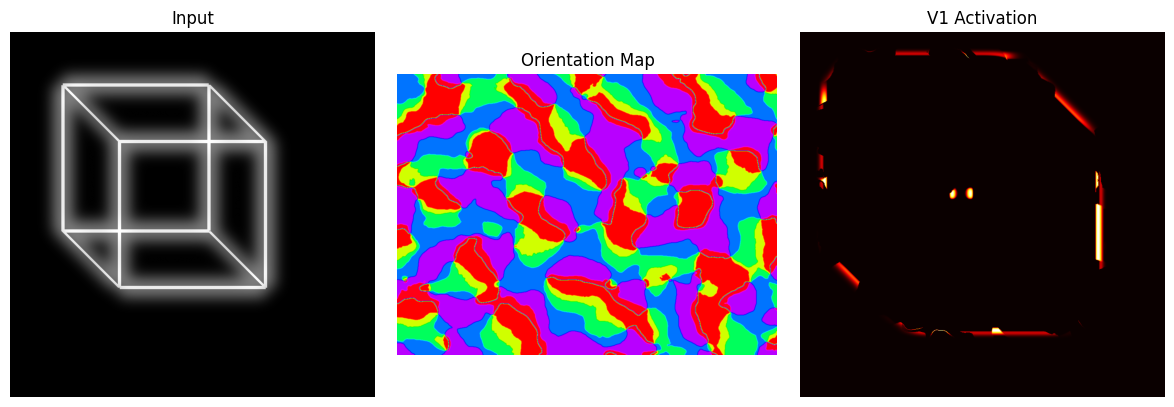

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter

# ------------------------------------------------------------
# 1. Load and convert orientation map image → radians
# ------------------------------------------------------------

def load_orientation_map(path):
    img = Image.open(path).convert("RGB")
    img = np.array(img) / 255.0
    H, W, _ = img.shape

    # Reference colors (approx)
    colors = np.array([
        [1.0, 0.0, 0.0],   # red → 0°
        [1.0, 0.5, 0.0],   # orange → 30°
        [1.0, 1.0, 0.0],   # yellow → 60°
        [0.0, 1.0, 0.0],   # green → 90°
        [0.0, 0.0, 1.0],   # blue → 120°
        [0.5, 0.0, 1.0],   # purple → 150°
    ])

    angles = np.deg2rad([0, 30, 60, 90, 120, 150])

    pixels = img.reshape(-1, 3)
    dists = np.linalg.norm(pixels[:, None, :] - colors[None, :, :], axis=2)
    idx = np.argmin(dists, axis=1)

    ori_map = angles[idx].reshape(H, W)

    # smooth (important)
    ori_map = gaussian_filter(ori_map, sigma=1.0)

    return ori_map


# ------------------------------------------------------------
# 2. Gabor filter
# ------------------------------------------------------------

def gabor(theta, lam=8.0, sigma=3.0, gamma=0.5, size=31):
    ax = np.arange(size) - size // 2
    X, Y = np.meshgrid(ax, ax)

    x_p = X * np.cos(theta) + Y * np.sin(theta)
    y_p = -X * np.sin(theta) + Y * np.cos(theta)

    gauss = np.exp(-(x_p**2 + gamma**2 * y_p**2) / (2 * sigma**2))
    carrier = np.cos(2 * np.pi * x_p / lam)

    return gauss * carrier


# ------------------------------------------------------------
# 3. Fast convolution
# ------------------------------------------------------------

def conv2d_fft(image, kernel):
    pad = kernel.shape[0] // 2
    img_p = np.pad(image, pad, mode="reflect")

    f_img = np.fft.fft2(img_p)

    k = np.flipud(np.fliplr(kernel))
    k_p = np.pad(k, (
        (0, img_p.shape[0] - k.shape[0]),
        (0, img_p.shape[1] - k.shape[1])
    ))

    f_k = np.fft.fft2(k_p)

    conv = np.fft.ifft2(f_img * f_k).real
    return conv[pad:-pad, pad:-pad]


# ------------------------------------------------------------
# 4. LGN preprocessing (DoG)
# ------------------------------------------------------------

def lgn_filter(stim):
    N = stim.shape[0]

    x = np.arange(N) - N // 2
    X, Y = np.meshgrid(x, x)

    center = np.exp(-(X**2 + Y**2) / (2 * 1.0**2))
    surround = np.exp(-(X**2 + Y**2) / (2 * 3.0**2))

    DoG = center - surround

    return np.fft.ifft2(
        np.fft.fft2(stim) * np.fft.fft2(np.fft.ifftshift(DoG))
    ).real


# ------------------------------------------------------------
# 5. Build Gabor bank (efficient)
# ------------------------------------------------------------

def build_gabor_bank(n_orient=16):
    thetas = np.linspace(0, np.pi, n_orient, endpoint=False)
    bank = [gabor(t) for t in thetas]
    return thetas, bank


# ------------------------------------------------------------
# 6. Compute V1 afferent response
# ------------------------------------------------------------

def v1_response(lgn, ori_map, thetas, gabor_bank):
    N = lgn.shape[0]

    # Precompute all convolutions
    convs = [conv2d_fft(lgn, g) for g in gabor_bank]

    # Match each pixel to closest orientation
    ori_idx = np.argmin(
        np.abs(ori_map[..., None] - thetas), axis=-1
    )

    v1 = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            v1[i, j] = convs[ori_idx[i, j]][i, j]

    return np.maximum(v1, 0)


# ------------------------------------------------------------
# 7. Example stimulus (square or Necker cube)
# ------------------------------------------------------------

def make_square(N=128):
    img = np.zeros((N, N))
    m = N // 4
    img[m:-m, m:-m] = 1
    return img

import numpy as np


def make_necker_cube(N=128, size=50, offset=20, thickness=1):
    """
    Generates a Necker cube line drawing.

    Parameters:
    - N: image size
    - size: size of front square
    - offset: shift between front and back square
    - thickness: line thickness
    """

    img = np.zeros((N, N))

    cx, cy = N // 2, N // 2

    # Front square
    f = [
        (cx - size//2, cy - size//2),
        (cx + size//2, cy - size//2),
        (cx + size//2, cy + size//2),
        (cx - size//2, cy + size//2),
    ]

    # Back square (shifted up-left)
    b = [(x - offset, y - offset) for (x, y) in f]

    # Draw front square
    for i in range(4):
        draw_line(img, *f[i], *f[(i+1)%4], thickness)

    # Draw back square
    for i in range(4):
        draw_line(img, *b[i], *b[(i+1)%4], thickness)

    # Connect corners
    for i in range(4):
        draw_line(img, *f[i], *b[i], thickness)

    return img

# ------------------------------------------------------------
# 8. Run everything
# ------------------------------------------------------------

# Load orientation map (your uploaded image)
ori_map = load_orientation_map("/content/Visual_Cortex.png")

# Resize input to match map
N = ori_map.shape[0]
print (N)
# Stimulus
# stim = make_square(N)
from scipy.ndimage import gaussian_filter
stim = gaussian_filter(make_necker_cube(N, size=310, offset=120, thickness=20), sigma=15)+make_necker_cube(N, size=310, offset=120, thickness=3)
# LGN
lgn = lgn_filter(stim)

# Gabor bank
thetas, gabor_bank = build_gabor_bank(16)

# V1 activation
v1 = v1_response(lgn, ori_map, thetas, gabor_bank)

# ------------------------------------------------------------
# 9. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(stim, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ori_map, cmap="hsv")
plt.title("Orientation Map")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(v1, cmap="hot")
plt.title("V1 Activation")
plt.axis("off")

plt.tight_layout()
plt.show()

[[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 4.73262214e-15
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 6.89129023e-14 ... 0.00000000e+00
   2.36137646e-14 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   1.57200027e-16 0.00000000e+00]
  ...
  [1.10527014e-13 1.35532926e-13 9.59052109e-14 ... 1.20224796e-14
   4.30850221e-14 6.60653647e-14]
  [4.11093710e-14 4.66248915e-14 2.00075609e-14 ... 5.83217229e-14
   3.06275281e-14 6.89315426e-15]
  [0.00000000e+00 5.68802020e-14 2.11309003e-16 ... 1.57236653e-14
   4.42479213e-15 2.97690978e-14]]

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 6.88211543e-15
   0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 6.82625871e-14 ... 0.00000000e+00
   2.24187496e-14 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  ...
  [1.13229383e-13 1.34837573e-13 9.48740063e-14 ... 1.20217680e-14
   4.23387

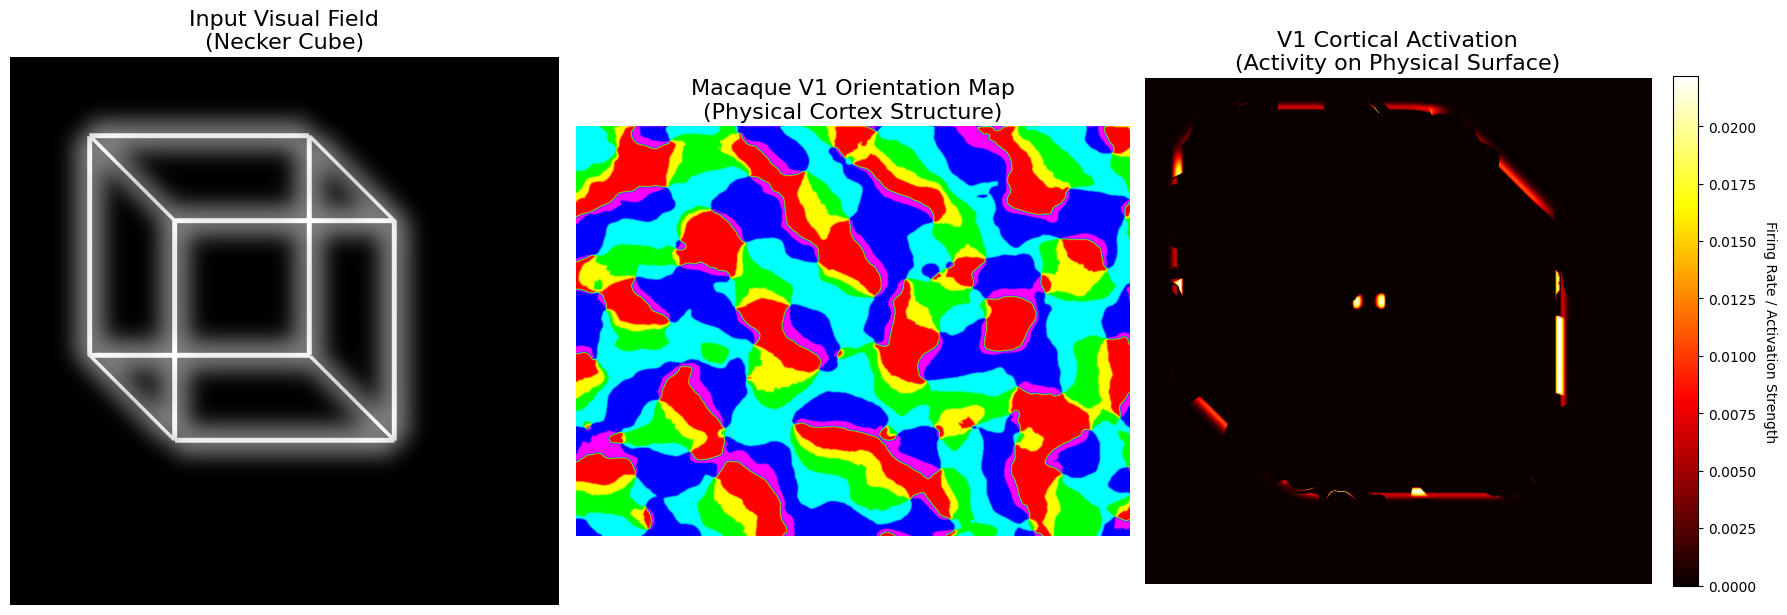

In [9]:
import numpy as np

def v1_population_response(lgn, thetas, gabor_bank):
    """
    Computes standard V1 simple cell responses (Linear-Nonlinear model).
    Instead of a 2D array, it returns a 3D tensor representing a full
    hypercolumn (all orientations) at every spatial location (x, y).

    Returns:
    - v1_tensor: shape (H, W, num_orientations)
    """
    N = lgn.shape[0]
    n_orient = len(thetas)

    # Initialize 3D tensor: (x, y, orientation)
    v1_tensor = np.zeros((N, N, n_orient))

    for idx, gabor_filter in enumerate(gabor_bank):
        # 1. Linear step: Convolve visual input with the receptive field
        response = conv2d_fft(lgn, gabor_filter)

        # 2. Nonlinear step: Half-wave rectification (ReLU)
        # Neurons have a baseline firing rate and cannot fire at negative rates.
        v1_tensor[:, :, idx] = np.maximum(response, 0)

    return v1_tensor
def map_to_cortical_sheet(v1_tensor, ori_map, thetas):
    """
    Projects the 3D V1 hypercolumn responses onto the 2D physical cortical sheet.
    This simulates the physical layout of the "iso-orientation patches"
    from the macaque V1 map.
    """
    N = v1_tensor.shape[0]
    cortex_activation = np.zeros((N, N))

    # Find the index of the closest theta for every pixel on the physical map
    ori_idx = np.argmin(np.abs(ori_map[..., None] - thetas), axis=-1)

    # For each physical neuron (pixel on the cortex), grab the response
    # of its preferred orientation from the visual field
    for i in range(N):
        for j in range(N):
            # i, j represents retinotopic location
            # ori_idx[i, j] represents the specific pinwheel slice at that location
            cortex_activation[i, j] = v1_tensor[i, j, ori_idx[i, j]]

    return cortex_activation
  # ... [Load your orientation map, build LGN, build Gabor bank] ...

# 1. Get the full biological feature representation (3D Tensor)
v1_features = v1_population_response(lgn, thetas, gabor_bank)
print(v1_features)

# 2. (Optional) Visualize what the physical brain surface looks like lighting up
physical_cortex = map_to_cortical_sheet(v1_features, ori_map, thetas)
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import numpy as np

# --- Assumes stim, ori_map, and physical_cortex are already in memory ---

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Plot the Input Stimulus
axes[0].imshow(stim, cmap='gray')
axes[0].set_title('Input Visual Field\n(Necker Cube)', fontsize=16)
axes[0].axis('off')

# 2. Plot the Structural Orientation Map
# We convert the radian angles (0 to pi) back into a colorful HSV image
# where the hue represents the preferred orientation.
hue = ori_map / np.pi
sat = np.ones_like(hue)
val = np.ones_like(hue)
hsv_map = np.stack([hue, sat, val], axis=-1)
rgb_map = hsv_to_rgb(hsv_map)

axes[1].imshow(rgb_map)
axes[1].set_title('Macaque V1 Orientation Map\n(Physical Cortex Structure)', fontsize=16)
axes[1].axis('off')

# 3. Plot the Final Cortical Activation
# We use the 'hot' colormap to simulate the "glowing" neurons.
# High values (bright yellow/white) mean strong firing rates.
im = axes[2].imshow(physical_cortex, cmap='hot')
axes[2].set_title('V1 Cortical Activation\n(Activity on Physical Surface)', fontsize=16)
axes[2].axis('off')

# Add a colorbar to the activation map to show the intensity scale
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Firing Rate / Activation Strength', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

# 3. For your Hopfield Network:
# You should feed 'v1_features' into your network, NOT 'physical_cortex'.
# The brain makes decisions based on the full feature space, not the 2D layout.

#Attempt to mimic higher levels of the visual cortex

In [10]:
import numpy as np
from skimage.transform import resize

ori_map_resized = resize(
    ori_map,
    v1.shape,
    order=1,               # bilinear
    preserve_range=True,
    anti_aliasing=True
)
def get_edge_mask(v1, percentile=90):
    thresh = np.percentile(v1, percentile)
    mask = v1 > thresh
    return mask
from scipy.ndimage import map_coordinates

def depth_ownership_map(v1, ori_map, mask, d=2):
    H, W = v1.shape

    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    # normals
    nx = np.cos(ori_map + np.pi/2)
    ny = np.sin(ori_map + np.pi/2)

    # sample coordinates
    x1 = x + d * nx
    y1 = y + d * ny
    x2 = x - d * nx
    y2 = y - d * ny

    # bilinear sampling
    s1 = map_coordinates(v1, [y1, x1], order=1, mode='constant')
    s2 = map_coordinates(v1, [y2, x2], order=1, mode='constant')

    depth = (s1 - s2)

    # keep only edges
    depth *= mask

    return depth
def build_depth_neurons(depth_map, ori_map, n_bins=16):
    neurons = []

    bins = np.linspace(-np.pi, np.pi, n_bins+1)

    for i in range(n_bins):
        mask = (ori_map >= bins[i]) & (ori_map < bins[i+1])

        if np.sum(mask) == 0:
            neurons.append(0)
        else:
            val = np.mean(depth_map[mask])
            neurons.append(val)

    neurons = np.array(neurons)

    # binarize
    neurons = np.sign(neurons)
    neurons[neurons == 0] = -1

    return neurons
def extract_depth_features(v1, ori_map):
    mask = get_edge_mask(v1, percentile=90)
    depth_map = depth_ownership_map(v1, ori_map, mask)
    neurons = build_depth_neurons(depth_map, ori_map, n_bins=16)
    return neurons
v1_amb = v1_response(lgn_filter(make_necker_cube(N,310,120,3)), ori_map_resized, thetas, gabor_bank)
v1_fa  = v1_response(lgn_filter(make_fap_cube(N,310,120,3,0.0)), ori_map_resized, thetas, gabor_bank)
v1_fb  = v1_response(lgn_filter(make_fbp_cube(N,310,120,3,0.0)), ori_map_resized, thetas, gabor_bank)

pattern_FA = extract_depth_features(v1_fa, ori_map_resized)
pattern_FB = extract_depth_features(v1_fb, ori_map_resized)
state_init = extract_depth_features(v1_amb, ori_map_resized)
print(pattern_FA)
print(pattern_FB)
print(state_init)

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1. -1.  1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1.  1. -1.  1.  1. -1.  1. -1. -1.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1. -1.  1. -1. -1.]
